In [ ]:
%pip install qiskit numpy
%pip install pylatexenc
%pip install qiskit_aer
%pip install qiskit
%pip install qiskit-aer qiskit-ibm-runtime

In [ ]:
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import Aer, AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService

# import basic plot tools
from qiskit.visualization import plot_histogram

# The MaxCut problem



Given a graph $G = (V,E)$, partition the vertices into two sets $S$ and $\bar{S}$
to maximize the number of edges crossing the partition. Encode each vertex $i$
with a bit $x_i \in \{0,1\}$, where $x_i$ indicates which side it is on. The
classical cost function is

$
C(x)
=
\sum_{(i,j)\in E} x_i(1-x_j) + x_j(1-x_i)
=
\sum_{(i,j)\in E} \left[x_i + x_j - 2x_i x_j\right].
$

This equals $1$ if the edge is cut, meaning the endpoints are on different
sides, and $0$ otherwise.



In quantum form, replace bits by qubits. Using Pauli $Z$, the cut indicator for edge $(i, j)$ becomes

$C_{ij} = \frac{1 - Z_i Z_j}{2}.$


So the cost Hamiltonian is

$H_C = \sum_{(i,j) \in E} \frac{1 - Z_i Z_j}{2}.$


The goal is to prepare a quantum state whose measurement gives bitstrings $x$ with large $C(x)$.



Instead of the uniform initial state, we will use a biased state using quantum state preparation(**QSP) with Walsh serie**s.

We will try to find a max cut for $C_5$


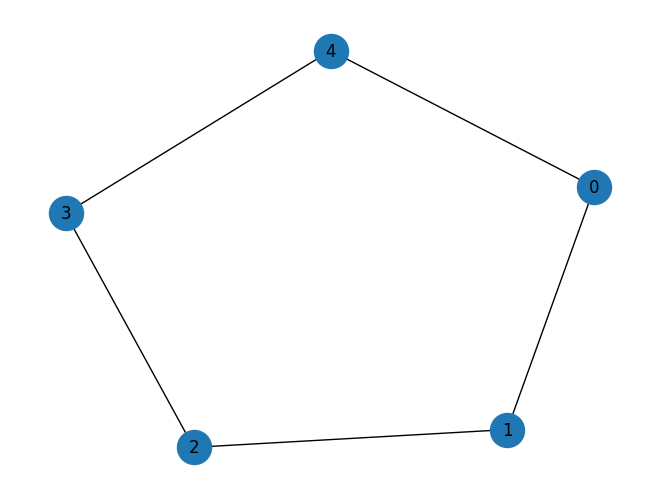

In [ ]:
# ---------------------------------------------------------------------------
# 1. Graph: C5 cycle, vertices 0-1-2-3-4-0 (non-bipartite, odd cycle)
# ---------------------------------------------------------------------------
n_small = 5

graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n_small, 1))
edge_list = [
    (0, 1, 1.0),
    (2, 3, 1.0),
    (3, 4, 1.0),
    (1, 2, 1.0),
    (4, 0, 1.0),
]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

# From classical optimization to quantum circuits





Map the classical graph into quantum **circuits** and **operators** . For unweighted max-cut the cost Hamiltonian reduces to $H_C = \sum_{(i,j)\in E} Z_i Z_j$, and QAOA uses a parametrized ansatz circuit to prepare candidate ground states of $H_C$.



# Appendix A1


In the appendix, the Walsh Series Loader loads a real-valued function

$f:[0,1]→ℝ$

into an n-qubit quantum state starts with the discretization of the interval [0,1] into $N=2^n$ discrete points
$
\chi=\{0,\frac{1}{N},\cdots,\frac{N-1}{N}\}
$

For Max-Cut, we reinterpret this function as a function on bitstrings, because each bitstring represents one cut.

For Max-Cut with n vertices, there are exactly $N=2^n$ possible bitstrings $x=x_1​x_2\cdots x_n​∈ \{0,1\}^n$.

Each bitstring represents a partition $S=\{i:x_i=1\}$ and its complement.




In [ ]:
## prepare the circuit
# parameters
m = len(edge_list)
epsilon0 = 0.1
lamda = 1
a_f = -lamda / (2 * m)


In [ ]:
def controlled_Walsh(qc, control, position_qubits, support, coeff):
    """
    Implements controlled exp(i coeff Z_0 Z_1 ... Z_{m-1}).
    """
    if len(support) == 0:
        qc.p(coeff, control)
        return

    if len(support) == 1:
        qc.crz(-2 * coeff, control, position_qubits[support[0]])
        return

    target = position_qubits[support[-1]]

    for q in support[:-1]:
        qc.cx(position_qubits[q], target)

    qc.crz(-2 * coeff, control, target)

    for q in reversed(support[:-1]):
        qc.cx(position_qubits[q], target)

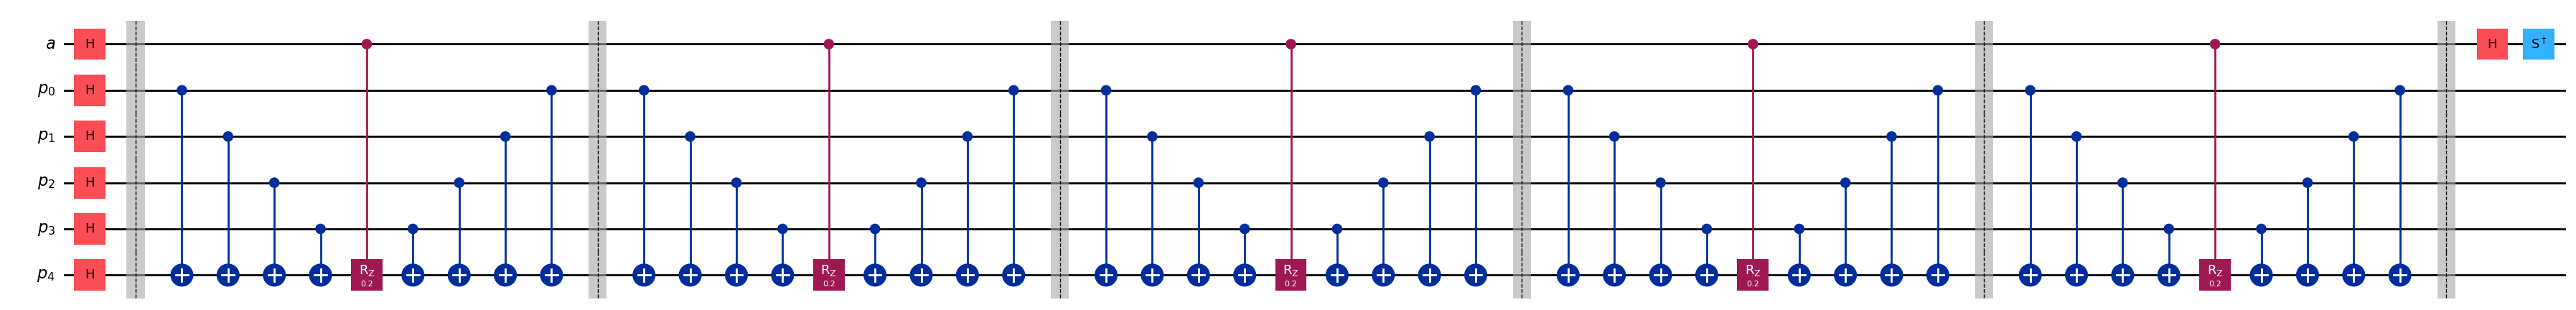

In [ ]:
ancilla_qubit = QuantumRegister(1, name="a")
position_qubits = QuantumRegister(m, name="p")

qc = QuantumCircuit(ancilla_qubit, position_qubits)

qc.h(ancilla_qubit)
qc.h(position_qubits)
qc.barrier()

walsh_terms = [(list(range(m)), a_f) for _ in range(m)]

for support, coeff in walsh_terms:
    controlled_Walsh(qc, ancilla_qubit, position_qubits, support, coeff)
    qc.barrier()

# Final ancilla interference
qc.h(ancilla_qubit)
qc.sdg(ancilla_qubit)

qc.draw("mpl", fold=-1)

In [ ]:
qc_sim = qc.copy()
qc_sim.save_statevector()

simulator = AerSimulator(method="statevector")

tqc = transpile(qc_sim, simulator)
result = simulator.run(tqc).result()

full_state = np.asarray(result.get_statevector(tqc))

print("Number of qubits:", qc.num_qubits)
print("Statevector dimension:", len(full_state))

Number of qubits: 6
Statevector dimension: 64


In [ ]:
def reconstruct_f_from_statevector(full_state, n):
    """
    Reconstructs f(x) from the final state.
    """

    N = 2**n

    f_vals = np.zeros(N)
    labels = []

    for x in range(N):
        idx0 = (x << 1) | 0   # ancilla = 0
        idx1 = (x << 1) | 1   # ancilla = 1

        A0 = full_state[idx0]
        A1 = full_state[idx1]

        Ux = (A0 - 1j * A1) / (A0 + 1j * A1)

        f_vals[x] = np.angle(Ux)

        # bitstring in p[0] p[1] ... p[m-1] order
        labels.append(format(x, f"0{n}b")[::-1])

    return labels, f_vals


labels, f_quantum = reconstruct_f_from_statevector(full_state, m)

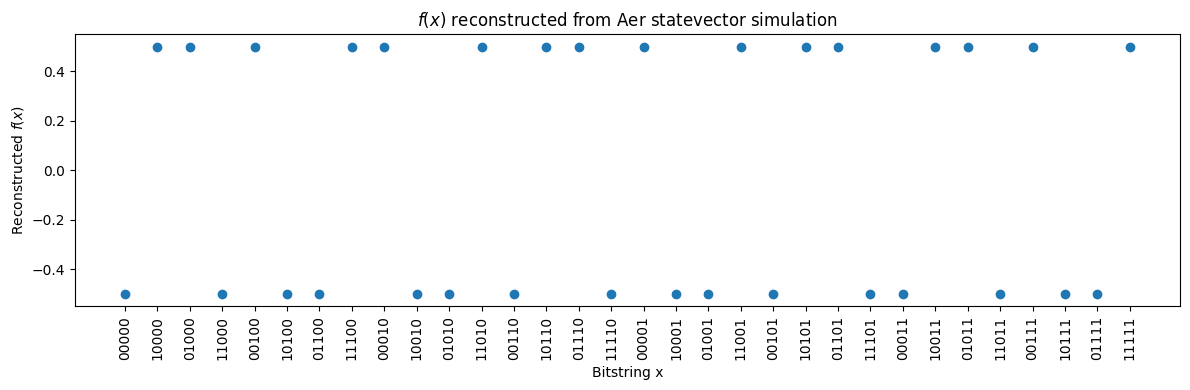

In [ ]:
plt.figure(figsize=(12, 4))
plt.scatter(labels, f_quantum)
plt.xlabel("Bitstring x")
plt.ylabel(r"Reconstructed $f(x)$")
plt.title(r"$f(x)$ reconstructed from Aer statevector simulation")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Connect to server

In [ ]:
def build_wsl_circuit_for_sampler(num_position_qubits, walsh_terms):
    ancilla = QuantumRegister(1, name="a")
    position = QuantumRegister(num_position_qubits, name="p")
    meas = ClassicalRegister(num_position_qubits + 1, name="meas")

    qc = QuantumCircuit(ancilla, position, meas)

    a = ancilla[0]

    qc.h(a)
    qc.h(position)
    qc.barrier()

    for support, coeff in walsh_terms:
        controlled_Walsh(qc, a, position, support, coeff)
        qc.barrier()

    qc.h(a)
    qc.sdg(a)

    qc.measure(a, meas[0])

    for i in range(num_position_qubits):
        qc.measure(position[i], meas[i + 1])

    return qc

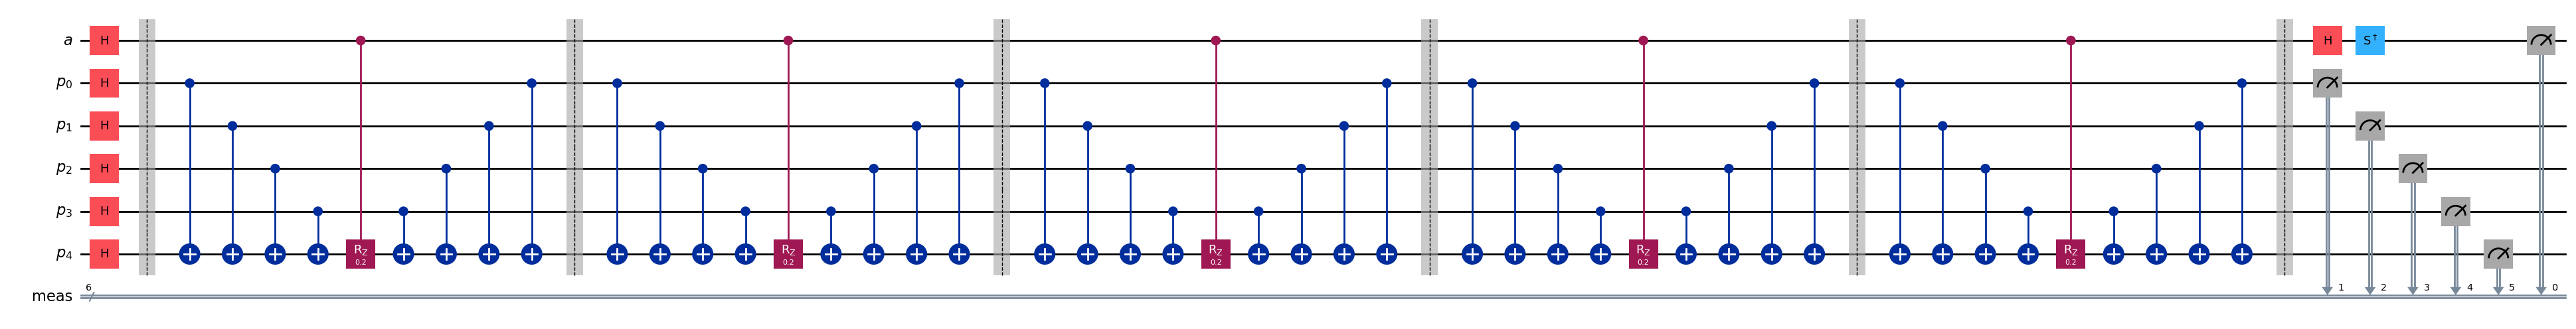

In [ ]:
def controlled_Walsh(qc, control, position_qubits, support, coeff):
    """
    Implements controlled exp(i coeff * prod_{q in support} Z_q).
    """

    if len(support) == 0:
        qc.p(coeff, control)
        return

    if len(support) == 1:
        qc.crz(-2 * coeff, control, position_qubits[support[0]])
        return

    target = position_qubits[support[-1]]

    for q in support[:-1]:
        qc.cx(position_qubits[q], target)

    qc.crz(-2 * coeff, control, target)

    for q in reversed(support[:-1]):
        qc.cx(position_qubits[q], target)

walsh_terms = [(list(range(m)), a_f) for _ in range(m)]

qc_measure = build_wsl_circuit_for_sampler(num_position_qubits=m, walsh_terms=walsh_terms)

qc_measure.draw("mpl", fold=-1)

In [ ]:
# from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
# from qiskit import transpile

import os
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler


QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="jrX82PGt-sRidN3Be11GPxCFFgVY87WnG0q6x5V3Ezfk",
    overwrite=True)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

backend = service.backend("ibm_kingston")

print("Circuit qubits:", qc_measure.num_qubits)
print("Backend qubits:", backend.num_qubits)

qiskit_runtime_service.__init__:WARNING:2026-07-11 00:29:19,228: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-11 00:29:19,229: Using instance: open-instance, plan: open


Circuit qubits: 6
Backend qubits: 156


In [ ]:
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_qc = pm.run(qc_measure)

sampler = Sampler(mode=backend)

job = sampler.run([isa_qc], shots=5000)

print("Job ID:", job.job_id())
print("Status:", job.status())

result = job.result()
pub_result = result[0]

counts = pub_result.data.meas.get_counts()

print(counts)

Job ID: d98osoqf47jc73a86ov0
Status: QUEUED
{'010000': 156, '101010': 220, '010010': 67, '111010': 94, '100101': 30, '011010': 113, '110100': 132, '001010': 127, '101011': 16, '111100': 75, '111000': 164, '101110': 106, '001110': 174, '011100': 115, '000000': 161, '000010': 209, '001101': 17, '000110': 123, '100000': 240, '101000': 150, '000100': 189, '101101': 9, '100011': 26, '001100': 125, '110010': 166, '001000': 275, '010101': 16, '100100': 140, '001011': 13, '011110': 70, '011111': 21, '001001': 12, '010110': 103, '101100': 221, '000111': 19, '011000': 108, '100110': 183, '010011': 25, '100010': 135, '010100': 73, '110111': 19, '111110': 115, '110000': 88, '010001': 14, '100001': 13, '111101': 18, '101111': 25, '110110': 63, '000011': 10, '110011': 5, '011011': 7, '110001': 29, '111011': 25, '011001': 25, '100111': 13, '101001': 28, '010111': 7, '000001': 33, '001111': 7, '111001': 13, '110101': 10, '011101': 7, '000101': 6, '111111': 2}


In [ ]:
def postselect_ancilla_one(counts, num_position_qubits):
    """
    Counts keys are measured as strings.

    Since meas[0] is the ancilla, it appears as the rightmost bit
    in Qiskit's displayed bitstring.

    Example for n=4:
        key = "p3 p2 p1 p0 a"
        so key[-1] is ancilla.
    """

    post_counts = {}
    success_shots = 0
    total_shots = sum(counts.values())

    for key, count in counts.items():
        key = key.replace(" ", "")

        ancilla_bit = key[-1]
        position_bits_reversed = key[:-1]

        # Convert from p[n-1]...p[0] to p[0]...p[n-1]
        position_bits = position_bits_reversed[::-1]

        if ancilla_bit == "1":
            success_shots += count
            post_counts[position_bits] = post_counts.get(position_bits, 0) + count

    return post_counts, success_shots, total_shots

In [ ]:
post_counts, success_shots, total_shots = postselect_ancilla_one(
    counts,
    num_position_qubits=m
)

print("Total shots:", total_shots)
print("Success shots:", success_shots)
print("Success probability:", success_shots / total_shots)

print("Postselected counts:")
print(post_counts)

Total shots: 5000
Success shots: 520
Success probability: 0.104
Postselected counts:
{'01001': 30, '10101': 16, '01100': 17, '01101': 9, '10001': 26, '01010': 16, '10100': 13, '11110': 21, '00100': 12, '11000': 19, '10010': 25, '11011': 19, '00010': 14, '00001': 13, '01111': 18, '11101': 25, '10000': 10, '10011': 5, '10110': 7, '00011': 29, '10111': 25, '00110': 25, '11001': 13, '00101': 28, '11010': 7, '00000': 33, '11100': 7, '00111': 13, '01011': 10, '01110': 7, '01000': 6, '11111': 2}


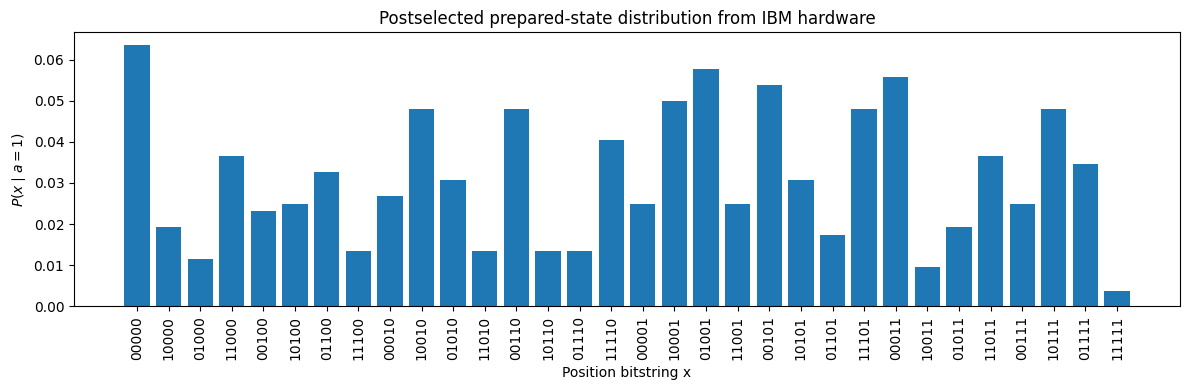

In [ ]:
labels = [
    "".join(str((x >> i) & 1) for i in range(m))
    for x in range(2**m)
]

post_probs = np.array([
    post_counts.get(label, 0) / success_shots
    for label in labels
])

plt.figure(figsize=(12, 4))
plt.bar(labels, post_probs)
plt.xlabel("Position bitstring x")
plt.ylabel(r"$P(x \mid a=1)$")
plt.title("Postselected prepared-state distribution from IBM hardware")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

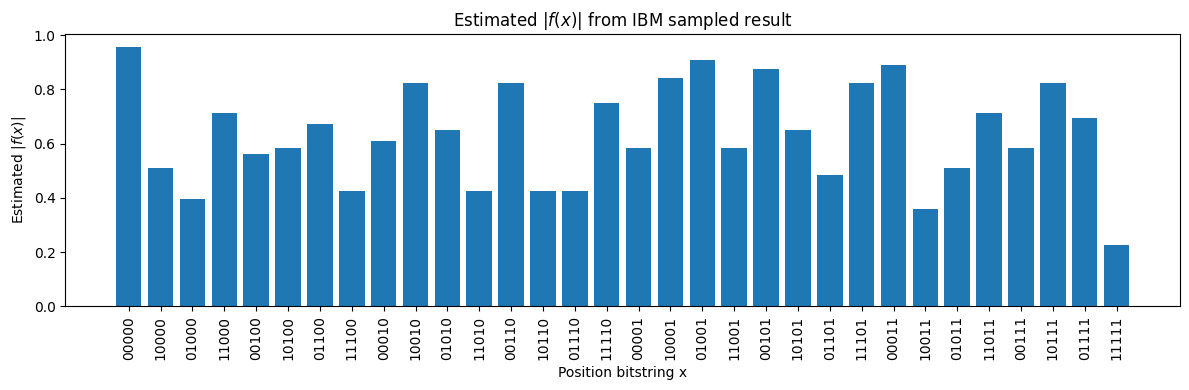

In [ ]:
joint_success_probs = np.array([
    post_counts.get(label, 0) / total_shots
    for label in labels
])

sin2_half_f = (2**m) * joint_success_probs
sin2_half_f = np.clip(sin2_half_f, 0.0, 1.0)

f_abs_est = 2 * np.arcsin(np.sqrt(sin2_half_f))

plt.figure(figsize=(12, 4))
plt.bar(labels, f_abs_est)
plt.xlabel("Position bitstring x")
plt.ylabel(r"Estimated $|f(x)|$")
plt.title(r"Estimated $|f(x)|$ from IBM sampled result")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()